In [1]:
import pandas as pd
import pdfplumber
import geopandas as gpd
import os
import numpy as np
import openpyxl as op
from pathlib import Path 
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [3]:
#EDA Step 1 — Merge all variables & map missingness/flags per PLR
csv = Path("../../data/real_estate/final_variables")

#load each variable's saved output (plr_id always as string)
v1 = pd.read_csv(csv / "var1_2_angebotsmieten.csv", dtype={"plr_id": str})
v3 = pd.read_csv(csv / "var3_leerstandsquote.csv", dtype={"plr_id": str})
v4 = pd.read_csv(csv / "var4_mietluecke.csv", dtype={"plr_id": str})
v5 = pd.read_csv(csv / "var5_brw_wohnen_features.csv", dtype={"plr_id": str})
v6 = gpd.read_file("../../data/real_estate/Geodata/var6_DichteAirBNB.gpkg")[
        ["plr_id", "dichte_all", "dichte_entire"]]
v6["plr_id"] = v6["plr_id"].astype(str).str.zfill(8)
v7 = pd.read_csv(csv / "var7_baualter.csv", dtype={"plr_id": str})

#master 542-PLR backbone (use the PLR geofile, the authoritative list)
plr_master = gpd.read_file("../../data/real_estate/Geodata/PLR_raw.geojson")[["plr_id", "plr_name", "bez"]]
plr_master["plr_id"] = plr_master["plr_id"].astype(str).str.zfill(8)
print("Master PLR:", plr_master.shape[0])

#merge everything (left joins onto the 542 backbone not to lose a PLR)
merged = (plr_master
    .merge(v1[["plr_id", "miete_niveau", "miete_trend", "miete_unsicher"]], on="plr_id", how="left")
    .merge(v3[["plr_id", "leerstandsquote"]], on="plr_id", how="left")
    .merge(v4[["plr_id", "rent_gap"]], on="plr_id", how="left")
    .merge(v5[["plr_id", "var5_brw_wohnen_niveau", "var5_brw_wohnen_trend",
               "var5_brw_wohnen_trend_outlier", "cov_wohnen_2025"]], on="plr_id", how="left")
    .merge(v6, on="plr_id", how="left")
    .merge(v7[["plr_id", "baualter_unsicher"] +
              [c for c in v7.columns if c.startswith("anteil_")]], on="plr_id", how="left")
)
print("Merged shape:", merged.shape)
assert len(merged) == 542, "Merge hat die PLR-Zahl verändert!"

#Map of missingness: one representative value-column per variable
leitspalten = {
    "var1_miete":   "miete_niveau",
    "var3_leer":    "leerstandsquote",
    "var4_gap":     "rent_gap",
    "var5_brw":     "var5_brw_wohnen_niveau",
    "var6_airbnb":  "dichte_entire", "dichte_all"
    "var7_baualter":"anteil_vor_1919",
}
print("\n--- Missing per variable (of 542 PLR) ---")
for label, col in leitspalten.items():
    print(f"{label:16} fehlt bei {merged[col].isna().sum():3} PLR")

#how many variables is each PLR missing?
miss_matrix = pd.DataFrame({lab: merged[col].isna() for lab, col in leitspalten.items()})
merged["n_missing_vars"] = miss_matrix.sum(axis=1)
print("\n--- PLR by number of missing variables ---")
print(merged["n_missing_vars"].value_counts().sort_index())

#the PLR missing at least one variable, with which ones
problem = merged[merged["n_missing_vars"] > 0].copy()
problem["missing_in"] = miss_matrix.loc[problem.index].apply(
    lambda r: ", ".join([lab for lab, v in r.items() if v]), axis=1)
print("\n--- PLR with any missing variable ---")
print(problem[["plr_id", "plr_name", "n_missing_vars", "missing_in"]].to_string(index=False))

#reliability flags (present but low-confidence, NOT missing)
print("\n--- Reliability flags (data present but flagged) ---")
print("miete_unsicher (fallzahl<21):     ", int(merged["miete_unsicher"].fillna(0).sum()))
print("brw_trend_outlier:                ", int(merged["var5_brw_wohnen_trend_outlier"].fillna(0).sum()))
print("brw cov_wohnen < 0.5:             ", int((merged["cov_wohnen_2025"].fillna(0) < 0.5).sum()))
print("baualter_unsicher (<50 Whg):      ", int(merged["baualter_unsicher"].fillna(0).sum()))

#save the merged matrix for the clustering stage
merged.to_csv(csv / "EDA_re_variables.csv", index=False)
print("\ngespeichert:", merged.shape, "-> df_all_BI.csv")

Master PLR: 542
Merged shape: (542, 22)

--- Missing per variable (of 542 PLR) ---
var1_miete       fehlt bei  11 PLR
var3_leer        fehlt bei   5 PLR
var4_gap         fehlt bei  20 PLR
var5_brw         fehlt bei   2 PLR
var6_airbnb      fehlt bei   2 PLR
dichte_allvar7_baualter fehlt bei   2 PLR

--- PLR by number of missing variables ---
n_missing_vars
0    521
1      9
2      8
3      1
4      1
5      2
Name: count, dtype: int64

--- PLR with any missing variable ---
  plr_id                          plr_name  n_missing_vars                                                            missing_in
03200204                      Blankenfelde               1                                                              var4_gap
03300413                         Karow Ost               2                                                  var1_miete, var4_gap
03300515               Blankenburger Süden               3                                       var1_miete, var3_leer, var4_gap
033005

In [4]:
#EDA Step 2 — Finalise the clustering PLR set (exclude non-residential)

#Bring dwelling counts onto the merged frame
whg = pd.read_excel("../../data/real_estate/raw/Anzahl_whg_PLR.xlsx", skiprows=2, dtype={0: str, 1: str})
whg.columns = ["plr_id", "wohnungen"]
whg = whg[whg["plr_id"].str.match(r"^\d{8}$", na=False)]
whg["wohnungen"] = pd.to_numeric(whg["wohnungen"].astype(str).str.replace(".", "", regex=False),
                                 errors="coerce")
whg["plr_id"] = whg["plr_id"].str.zfill(8)

# merge counts onto the 542-PLR frame
chk = merged.merge(whg, on="plr_id", how="left")

#flag: is the housing dimension applicable? (>=30 dwellings and a known count)
chk["miet_dimension_anwendbar"] = (~(
    chk["wohnungen"].isna() | (chk["wohnungen"] < 30)
)).astype(int)

print("Miet-Dimension anwendbar:", int(chk["miet_dimension_anwendbar"].sum()), "von", len(chk))
print("nicht anwendbar (flagged out):", int((chk["miet_dimension_anwendbar"] == 0).sum()))
print(chk.loc[chk["miet_dimension_anwendbar"] == 0,
              ["plr_id", "plr_name", "wohnungen", "n_missing_vars"]].to_string(index=False))

#candidates: PLR missing many variables, with dwelling count
kandidaten = chk[chk["n_missing_vars"] >= 2][
    ["plr_id", "plr_name", "n_missing_vars", "wohnungen"]
].sort_values(["n_missing_vars", "wohnungen"], ascending=[False, True])
print("\n--- PLR missing >=2 variables, with dwelling count ---")
print(kandidaten.to_string(index=False))

#dwelling-count thresholds
print("\n--- Dwelling-count thresholds across ALL 542 PLR ---")
for s in [0, 10, 30, 50, 100]:
    n = (chk["wohnungen"].fillna(0) <= s).sum()
    print(f"<= {s:3} Wohnungen: {n} PLR")
print("NaN wohnungen:", chk["wohnungen"].isna().sum())

#save the full 542-PLR frame WITH the flag (do not drop rows)
chk.to_csv(csv / "EDA_merged_all_variables.csv", index=False)
print("\ngespeichert (542, mit Flag):", chk.shape)

Miet-Dimension anwendbar: 537 von 542
nicht anwendbar (flagged out): 5
  plr_id                          plr_name  wohnungen  n_missing_vars
03300515               Blankenburger Süden       24.0               3
03400831                      Pankower Tor        NaN               5
05300838                        Gartenfeld        8.0               2
06200418                           Landweg        NaN               5
10100205 Gewerbegebiet Bitterfelder Straße       10.0               4

--- PLR missing >=2 variables, with dwelling count ---
  plr_id                          plr_name  n_missing_vars  wohnungen
03400831                      Pankower Tor               5        NaN
06200418                           Landweg               5        NaN
10100205 Gewerbegebiet Bitterfelder Straße               4       10.0
03300515               Blankenburger Süden               3       24.0
05300838                        Gartenfeld               2        8.0
04400725            Güterbahnhof 

#EDA what is to come -  step by step 
- Distributions — histogram each of the ~14 features, note skew --> decision for log-transformation 
- Correlations — heatmap. 
- Outliers & flags — overlay your reliability flags on the distributions; see whether flagged PLR are the tails.

#Log Transformation and then scaling / imputing and clustering matrix 
Then transform (log where needed) → scale → impute → clustering matrix.

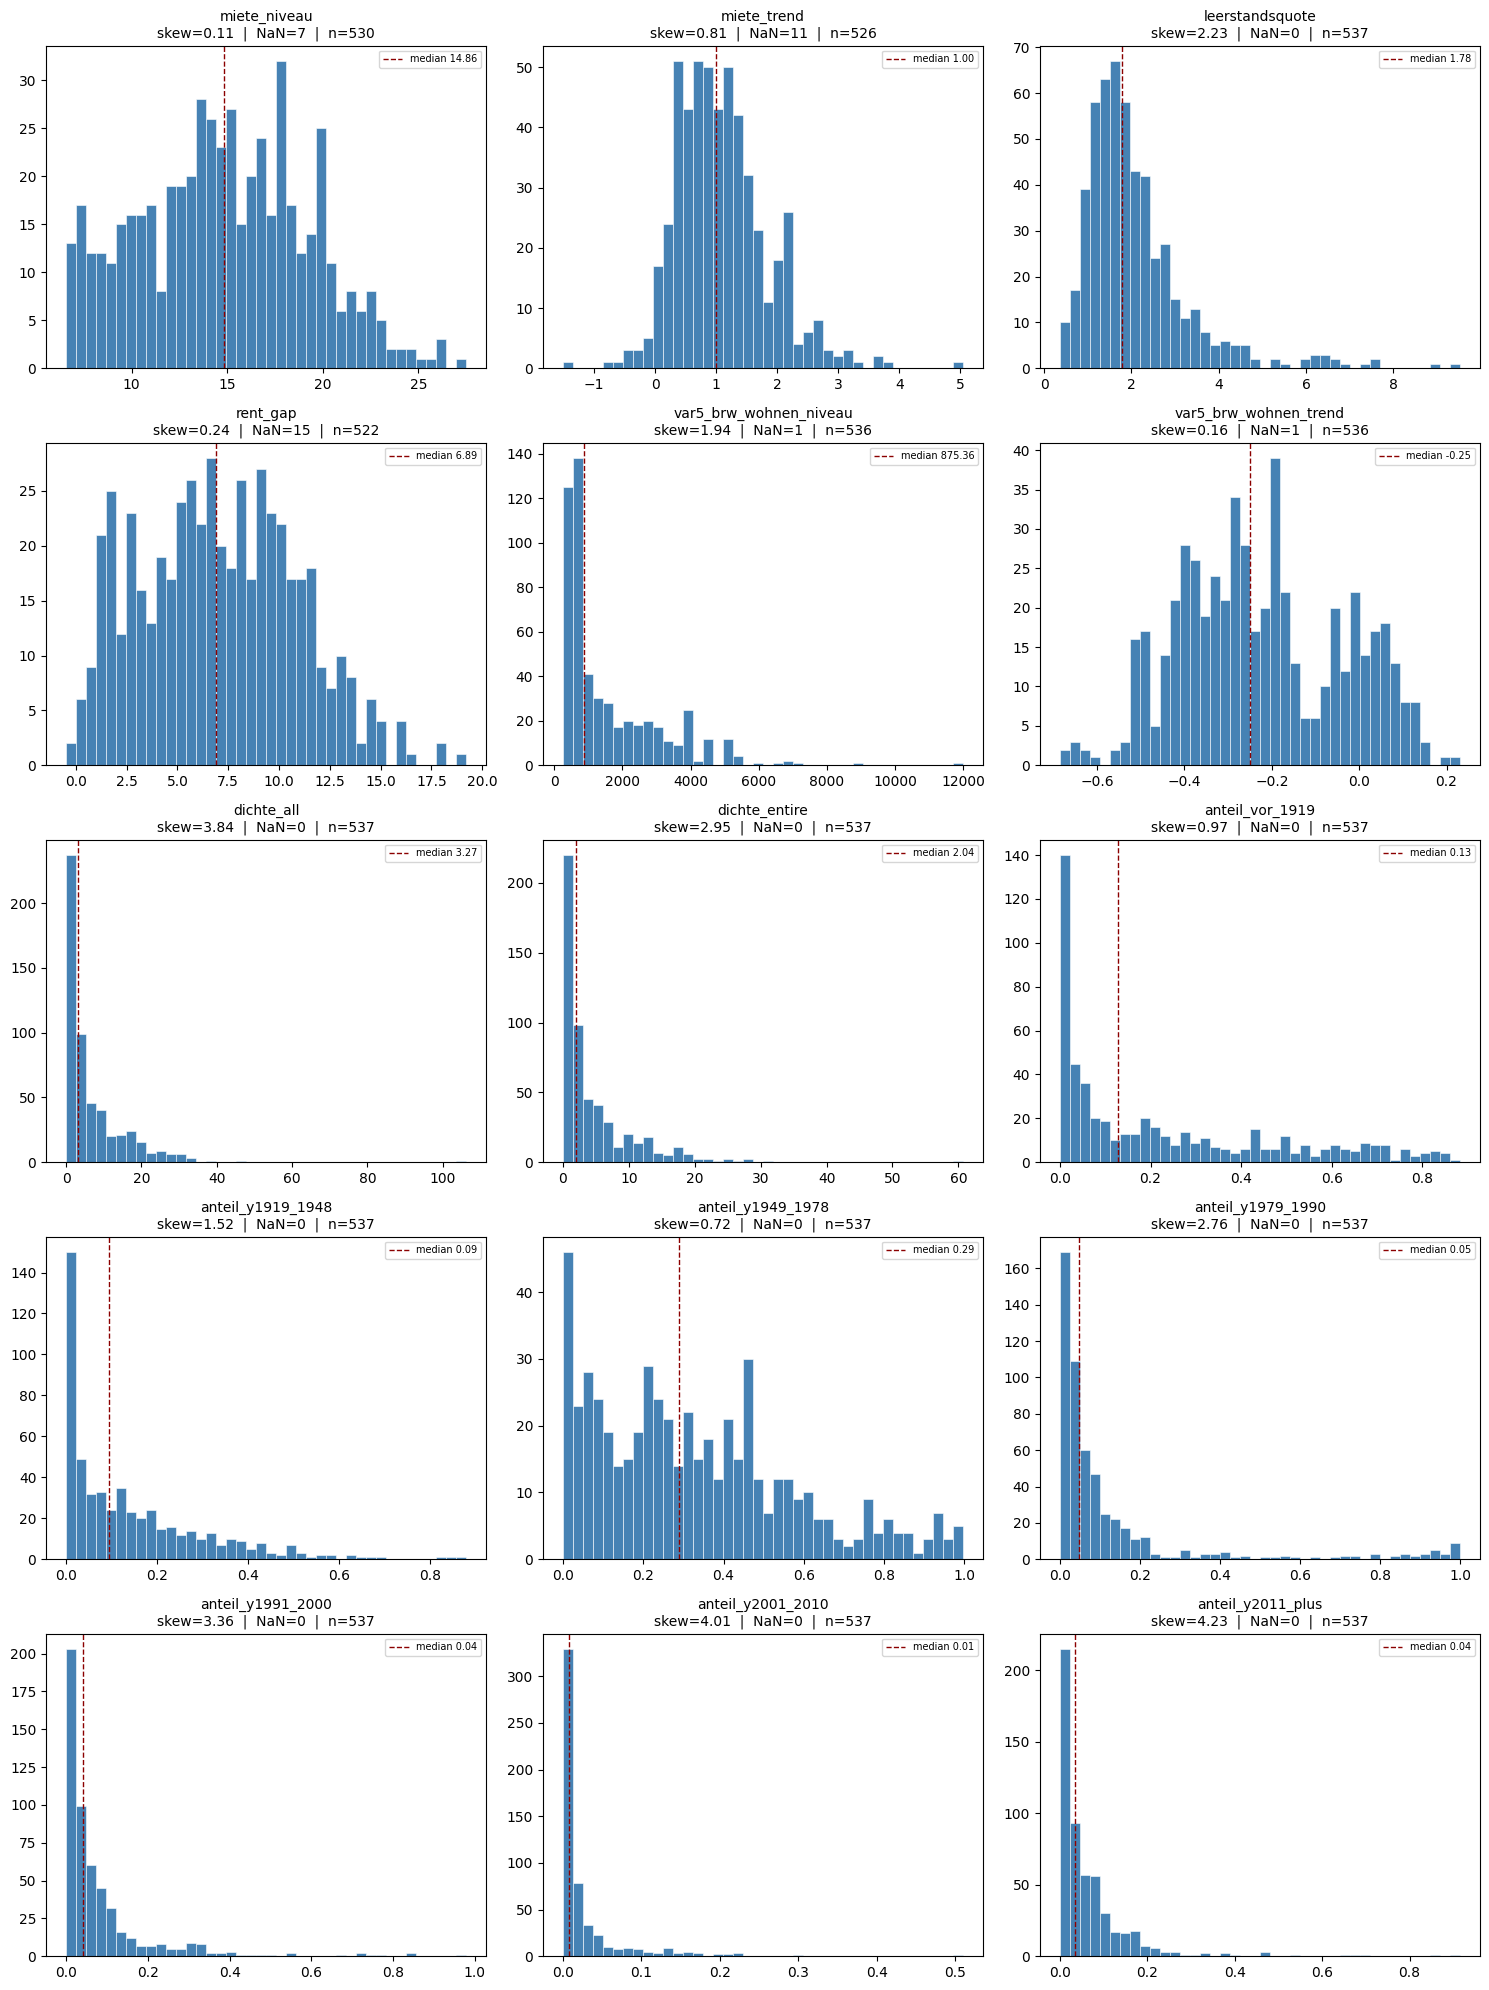

gespeichert: plots/EDA_histograms_537.png


In [6]:
#EDA - step 3: Distributions as histograms to decide which variables need log-transformation 
#clustering set (housing-dimension applicable)
cs = chk[chk["miet_dimension_anwendbar"] == 1].copy()

feature_cols = [
    "miete_niveau", "miete_trend", "leerstandsquote", "rent_gap",
    "var5_brw_wohnen_niveau", "var5_brw_wohnen_trend", "dichte_all", "dichte_entire",
    "anteil_vor_1919", "anteil_y1919_1948", "anteil_y1949_1978",
    "anteil_y1979_1990", "anteil_y1991_2000", "anteil_y2001_2010",
    "anteil_y2011_plus",
]

n = len(feature_cols)
ncols = 3
nrows = -(-n // ncols)  # ceil

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    data = cs[col].dropna()
    ax = axes[i]
    ax.hist(data, bins=40, color="steelblue", edgecolor="white", linewidth=0.4)
    skew = data.skew()
    n_na = cs[col].isna().sum()
    ax.set_title(f"{col}\nskew={skew:.2f}  |  NaN={n_na}  |  n={len(data)}", fontsize=10)
    ax.axvline(data.median(), color="darkred", linestyle="--", linewidth=1,
               label=f"median {data.median():.2f}")
    ax.legend(fontsize=7)

# hide any unused panels
for j in range(n, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("../../plots/EDA/real_estate/EDA_histograms_537.png", dpi=110, bbox_inches="tight")
plt.show()
print("gespeichert: plots/EDA_histograms_537.png")



#Distribution overview

The fifteen features fall into three groups by shape. Roughly symmetric and ready to use as-is: miete_niveau (skew 0.11), var5_brw_wohnen_trend (0.16), rent_gap (0.24), and miete_trend (0.81) — these are bell-ish or only mildly right-leaning, with the median sitting near the centre of mass. Moderately right-skewed: anteil_y1949_1978 (0.72) and anteil_vor_1919 (0.97), both spread across the full 0–1 range rather than piling at zero. Strongly right-skewed with a heavy concentration near zero and a long thin tail: leerstandsquote (2.23), var5_brw_wohnen_niveau (1.94), dichte_all (3.84), dichte_entire (2.95), and most of the recent-construction age shares — anteil_y1919_1948 (1.52), anteil_y1979_1990 (2.76), anteil_y1991_2000 (3.36), anteil_y2001_2010 (4.01), anteil_y2011_plus (4.23). In this last group a large number of PLR cluster at very low values while a handful of hotspots sit far out in the tail — the classic pattern that dominates distance-based clustering if left untransformed, because the few extreme PLR drive most of the variance.

#Decision for log transformation 

Before scaling, a log-style transform (np.log1p, valid since all are non-negative) is applied to the heavily right-skewed, zero-bounded features: leerstandsquote, var5_brw_wohnen_niveau, dichte_all, and dichte_entire. All seven building-age shares are log-transformed as a block — anteil_vor_1919, anteil_y1919_1948, anteil_y1949_1978, anteil_y1979_1990, anteil_y1991_2000, anteil_y2001_2010, and anteil_y2011_plus — so the age profile is treated consistently rather than transforming only the skewed bins. 

Left untransformed are the near-symmetric variables miete_niveau, miete_trend, rent_gap, and var5_brw_wohnen_trend. The two trend variables are deliberately not logged in any case, since they contain negative values (rates of change) for which a log transform is undefined and conceptually inappropriate.

Note on the age shares: the seven bins are compositional (they sum to ~1 per PLR). Applying log1p uniformly across all seven keeps the treatment consistent and tames the skew, but still handles them as independent features rather than a closed composition; a centred-log-ratio transform would be the stricter alternative if compositional structure were to be preserved.


#Step 4: The correlation matrix 

It takes the 537 housing-applicable PLR, computes pairwise Spearman (rank-based) correlations across the 15 raw features, and renders them as an annotated heatmap with a diverging red–blue scale (red = positive, blue = negative). 

Spearman was chosen because the raw features are heavily skewed; rank correlation is robust to those tails where Pearson would be distorted. It also prints all feature pairs with |ρ| > 0.6 as an actionable redundancy list. NaNs (rent_gap's 15) are handled by pairwise deletion.

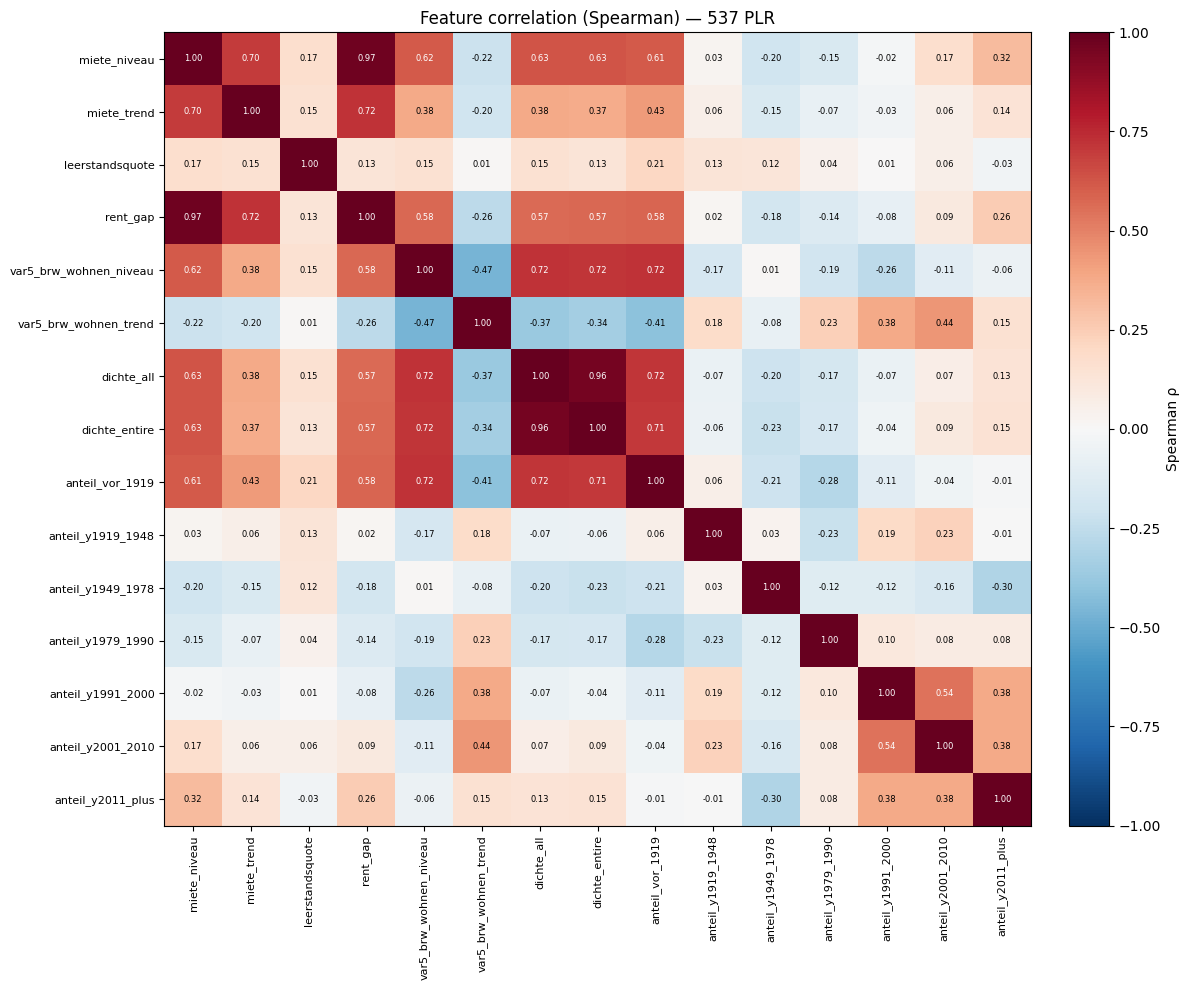

Strong pairs (|ρ| > 0.6):
  miete_niveau                 rent_gap                     +0.97
  dichte_entire                dichte_all                   +0.96
  dichte_all                   var5_brw_wohnen_niveau       +0.72
  miete_trend                  rent_gap                     +0.72
  anteil_vor_1919              var5_brw_wohnen_niveau       +0.72
  dichte_entire                var5_brw_wohnen_niveau       +0.72
  anteil_vor_1919              dichte_all                   +0.72
  dichte_entire                anteil_vor_1919              +0.71
  miete_niveau                 miete_trend                  +0.70
  dichte_entire                miete_niveau                 +0.63
  dichte_all                   miete_niveau                 +0.63
  var5_brw_wohnen_niveau       miete_niveau                 +0.62
  miete_niveau                 anteil_vor_1919              +0.61


In [7]:
#correlation heat matrix 

cs = chk[chk["miet_dimension_anwendbar"] == 1].copy()

feature_cols = [
    "miete_niveau", "miete_trend", "leerstandsquote", "rent_gap",
    "var5_brw_wohnen_niveau", "var5_brw_wohnen_trend",
    "dichte_all", "dichte_entire",
    "anteil_vor_1919", "anteil_y1919_1948", "anteil_y1949_1978",
    "anteil_y1979_1990", "anteil_y1991_2000", "anteil_y2001_2010",
    "anteil_y2011_plus",
]

#Spearman: rank-based, robust to the skew/outliers still present in raw features
corr = cs[feature_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=90, fontsize=8)
ax.set_yticklabels(feature_cols, fontsize=8)

#annotate each cell with the correlation value
for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        val = corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=6, color="white" if abs(val) > 0.5 else "black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman ρ")
ax.set_title("Feature correlation (Spearman) — 537 PLR", fontsize=12)
plt.tight_layout()
plt.savefig("../../plots/EDA/real_estate/EDA_correlation_537.png", dpi=110, bbox_inches="tight")
plt.show()

#print the strongest pairs (|ρ| > 0.6, excluding self-correlations)
print("Strong pairs (|ρ| > 0.6):")
pairs = (corr.where(~np.eye(len(corr), dtype=bool))
             .stack().sort_values(key=abs, ascending=False))
seen = set()
for (a, b), v in pairs.items():
    key = frozenset((a, b))
    if key not in seen and abs(v) > 0.6:
        print(f"  {a:28} {b:28} {v:+.2f}")
        seen.add(key)

#Correlation matrix - results and consequences 

The Spearman correlation matrix across the 15 candidate features (537 housing-applicable PLR) shows two near-perfect redundancies against an otherwise distinct structure. rent_gap correlates with miete_niveau at ρ = 0.97 (the gap is dominated by the 2025 asking rent and tracks rent level), and dichte_all with dichte_entire at ρ = 0.96 (entire-home density is a subset of total density). Keeping both members of each pair would double-weight those dimensions in the clustering distance, so rent_gap (also the more incomplete variable, 15 imputed PLR) and dichte_entire are dropped, retaining miete_niveau and dichte_all. Both remain in the dataset for description and mapping — only excluded as clustering inputs — reducing the feature set from 15 to 13.

The retained features are related but non-redundant. A central-gentrification axis links high rents, land values, short-let density, and pre-1919 stock (ρ ≈ 0.6–0.72); the BRW trend runs counter to it (ρ ≈ −0.45), capturing the redevelopment periphery; vacancy is essentially uncorrelated with everything (|ρ| ≤ 0.21), adding independent signal; and the age shares behave as a composition with weak, partly mechanical correlations, none redundant enough to drop.

The purpose is to ensure clustering distances reflect genuinely distinct dimensions rather than counting the same signal twice — removing the two redundant features stops rent level and Airbnb intensity from being over-represented, so each retained variable contributes its own information.

#EDA Step 5 - Outliers & flags — overlay your reliability flags on the distributions; see whether flagged PLR are the tails.

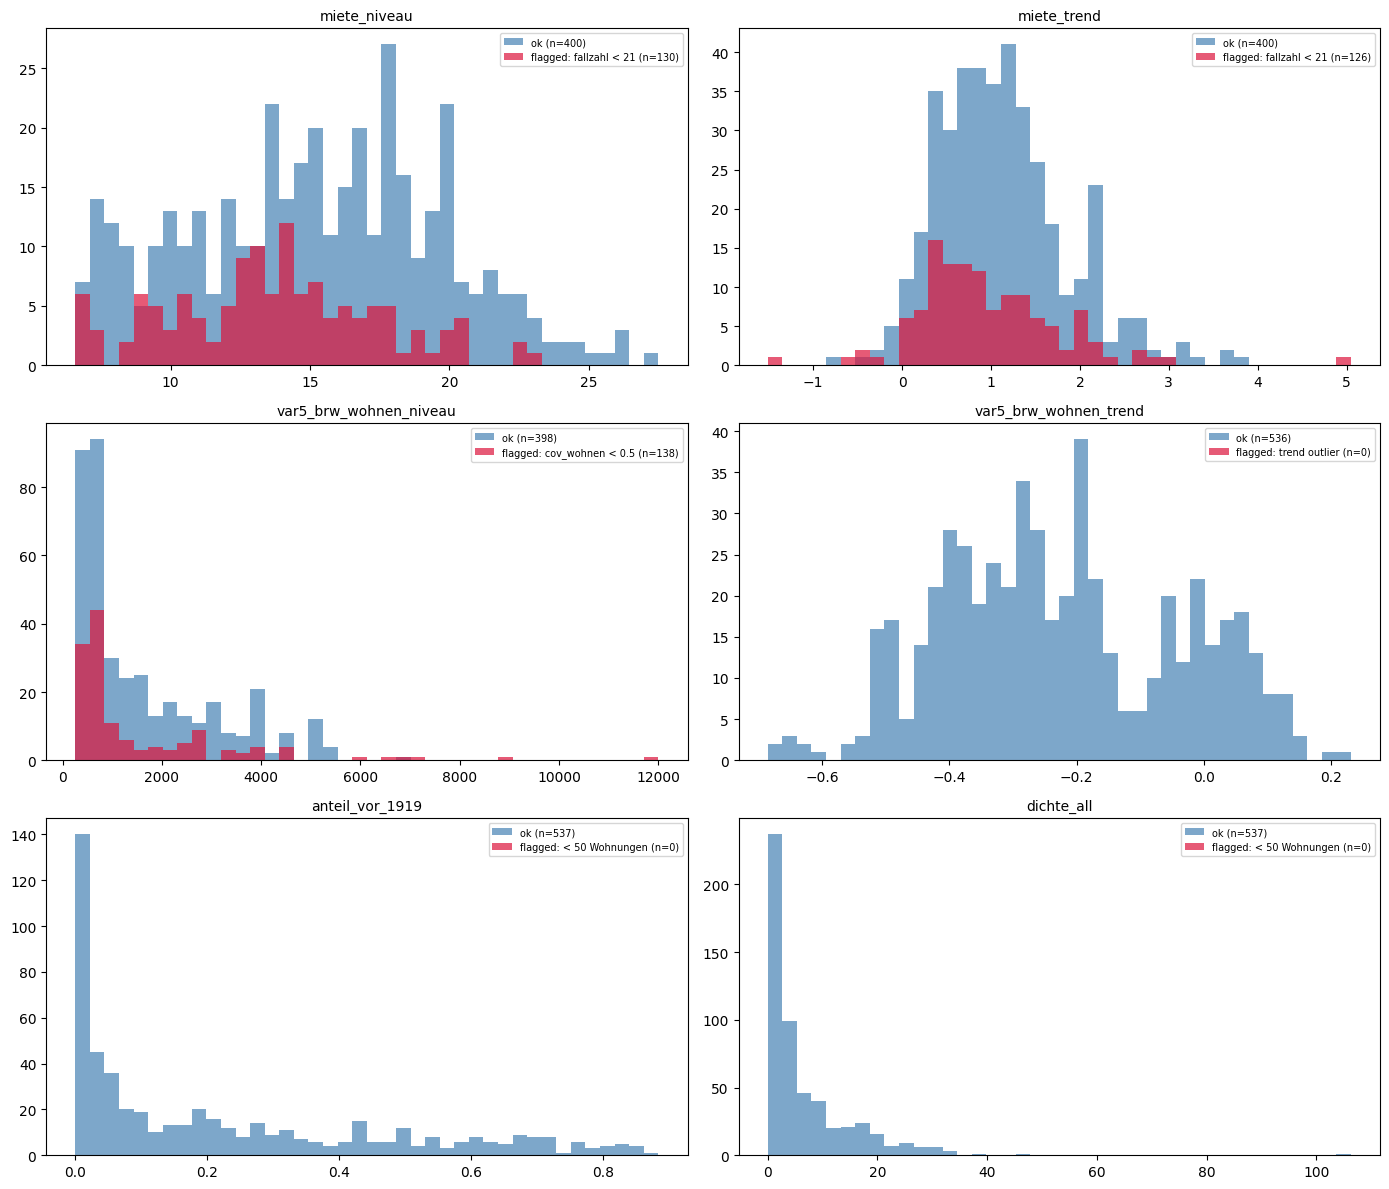

Flagged PLR position within each feature's distribution:
  miete_niveau               [fallzahl < 21     ] flagged median pctile=0.41  share in top/bottom 10%=13%
  miete_trend                [fallzahl < 21     ] flagged median pctile=0.40  share in top/bottom 10%=19%
  var5_brw_wohnen_niveau     [cov_wohnen < 0.5  ] flagged median pctile=0.44  share in top/bottom 10%=26%


In [8]:
cs = chk[chk["miet_dimension_anwendbar"] == 1].copy()

# (feature, flag column, flag meaning) — flag relevant to that feature
checks = [
    ("miete_niveau",            cs["miete_unsicher"].fillna(0) == 1,        "fallzahl < 21"),
    ("miete_trend",             cs["miete_unsicher"].fillna(0) == 1,        "fallzahl < 21"),
    ("var5_brw_wohnen_niveau",  cs["cov_wohnen_2025"].fillna(0) < 0.5,      "cov_wohnen < 0.5"),
    ("var5_brw_wohnen_trend",   cs["var5_brw_wohnen_trend_outlier"].fillna(0) == 1, "trend outlier"),
    ("anteil_vor_1919",         cs["baualter_unsicher"].fillna(0) == 1,     "< 50 Wohnungen"),
    ("dichte_all",              cs["baualter_unsicher"].fillna(0) == 1,     "< 50 Wohnungen"),
]

nrows = -(-len(checks) // 2)
fig, axes = plt.subplots(nrows, 2, figsize=(14, 4 * nrows))
axes = axes.flatten()

for i, (col, flag_mask, flag_label) in enumerate(checks):
    ax = axes[i]
    ok   = cs.loc[~flag_mask, col].dropna()
    flag = cs.loc[flag_mask,  col].dropna()
    # shared bins so the two overlays are comparable
    allvals = cs[col].dropna()
    bins = 40
    ax.hist(ok,   bins=bins, range=(allvals.min(), allvals.max()),
            color="steelblue", alpha=0.7, label=f"ok (n={len(ok)})")
    ax.hist(flag, bins=bins, range=(allvals.min(), allvals.max()),
            color="crimson", alpha=0.7, label=f"flagged: {flag_label} (n={len(flag)})")
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)

for j in range(len(checks), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("../../plots/EDA/real_estate/EDA_flags_overlay_537.png", dpi=110, bbox_inches="tight")
plt.show()

# numeric companion: where do flagged PLR sit? (median percentile of flagged vs all)
print("Flagged PLR position within each feature's distribution:")
for col, flag_mask, flag_label in checks:
    s = cs[col]
    flagged_vals = s[flag_mask].dropna()
    if len(flagged_vals) == 0:
        continue
    # percentile rank of each flagged PLR within the full distribution
    pct = s.rank(pct=True)[flag_mask].dropna()
    print(f"  {col:26} [{flag_label:18}] "
          f"flagged median pctile={pct.median():.2f}  "
          f"share in top/bottom 10%={(((pct>0.9)|(pct<0.1)).mean()):.0%}")

Outlier & flag check — results and consequences

Overlaying the reliability flags on their respective feature distributions shows that low-confidence PLR are not concentrated in the extreme tails, so they pose limited risk to the clustering. Two of the four flags are already resolved by the earlier exclusion of the five non-residential PLR: the single BRW trend outlier (Gartenfeld) and all building-age-unsicher PLR (< 50 dwellings) fall outside the 537-PLR clustering set, leaving no flagged cases for those features. Of the two flags that remain active, the thin-rent-data PLR (miete_unsicher, n = 130) are spread across the rent distribution with only a mild lean toward lower values, and the thin-residential-coverage PLR (cov_wohnen < 0.5, n = 138) cluster at the lower end of the land-value distribution — both within the dense body of their distributions rather than as isolated extremes. 

Because no flag identifies a group of unreliable PLR sitting in the far tails, no active handling (winsorising, exclusion, or down-weighting) is required before clustering. The flags are therefore retained only as descriptive caveats, carried alongside the data so that any cluster later found to be driven by flagged PLR can be interpreted with appropriate caution.



*************
ab hier noch nicht relevant 
******

In [ ]:
#log transformation of all age shares of buildings (var7) 

age_cols = ["anteil_vor_1919","anteil_y1919_1948","anteil_y1949_1978",
            "anteil_y1979_1990","anteil_y1991_2000","anteil_y2001_2010","anteil_y2011_plus"]

A = cs[age_cols].copy()
# CLR needs strictly positive values; replace exact zeros with a tiny amount, then renormalise
eps = 1e-6
A = A.replace(0, eps)
#renormalise rows to sum to 1
A = A.div(A.sum(axis=1), axis=0) 
#geometric mean per PLR           
gm = np.exp(np.log(A).mean(axis=1))
#centred log-ratio          
clr = np.log(A.div(gm, axis=0))              
clr.columns = [f"clr_{c}" for c in age_cols]
print(clr.describe().round(2))

In [ ]:
#Before clustering  — Build standardized clustering matrix on 537 PLR

#clustering set: housing-dimension applicable only
cs = chk[chk["miet_dimension_anwendbar"] == 1].copy()
print("Clustering set:", cs.shape[0], "PLR")

#raw features fed to clustering (city-level standardization for all)
feature_cols = [
    "miete_niveau",            
    "miete_trend",             
    "leerstandsquote",         
    "rent_gap",                
    "var5_brw_wohnen_niveau",  
    "var5_brw_wohnen_trend",   
    "dichte_entire",           
    "anteil_vor_1919", "anteil_y1919_1948", "anteil_y1949_1978",
    "anteil_y1979_1990", "anteil_y1991_2000", "anteil_y2001_2010",
    "anteil_y2011_plus",       
]

X = cs[feature_cols].copy()

# how many features is each PLR missing (before imputation)?
cs["n_imputed_features"] = X.isna().sum(axis=1)
print("\nMissing-feature counts in clustering set:")
print(cs["n_imputed_features"].value_counts().sort_index())
print("\nPLR with any imputed feature:")
print(cs.loc[cs["n_imputed_features"] > 0, ["plr_id","plr_name","n_imputed_features"]].to_string(index=False))

# standardize on observed values only, then fill NaN with 0 (= mean on z-scale)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols, index=cs.index)
n_nan_before = X_scaled.isna().sum().sum()
X_scaled = X_scaled.fillna(0.0)
print(f"\nNaN imputed to 0 (z-scale mean): {n_nan_before}")

# sanity: every standardized column mean≈0, std≈1 (on observed), no NaN left
print("\nStd-Check (über beobachtete Werte):")
print(X_scaled.std().round(3).to_string())
assert X_scaled.isna().sum().sum() == 0, "Noch NaN im Feature-Matrix!"

# assemble clustering-ready frame: ids + flags + standardized features
out = pd.concat([
    cs[["plr_id", "plr_name", "bez",
        "miete_unsicher", "var5_brw_wohnen_trend_outlier",
        "cov_wohnen_2025", "baualter_unsicher", "n_imputed_features"]].reset_index(drop=True),
    X_scaled.add_suffix("_z").reset_index(drop=True),
], axis=1)

out.to_csv(csv / "EDA_clustering_matrix_537.csv", index=False)
print("\ngespeichert:", out.shape, "-> EDA_clustering_matrix_537.csv")
out.head()

Ausgeschlossen (nicht-residenziell): 5
  plr_id                          plr_name  wohnungen  n_missing_vars
03300515               Blankenburger Süden       24.0               3
03400831                      Pankower Tor        NaN               5
05300838                        Gartenfeld        8.0               2
06200418                           Landweg        NaN               5
10100205 Gewerbegebiet Bitterfelder Straße       10.0               4

Clustering-Set: 537 PLR
davon mit fehlenden Variablen: 16
